In [2]:

# 检查显存
import torch
print(f"\nPyTorch CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM: {total:.1f} GB")

    if total < 30:
        print("\n WARNING: 显存 < 30GB，将自动切换到 Qwen2.5-Coder-3B + INT8")
    else:
        print("\n 显存充足，可以跑 Qwen2.5-Coder-7B FP16")


PyTorch CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
Total VRAM: 79.3 GB

 显存充足，可以跑 Qwen2.5-Coder-7B FP16


In [3]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Drive上的模型缓存目录
DRIVE_MODEL_DIR = '/content/drive/MyDrive/vllm_bench/models'
DRIVE_RESULTS_DIR = '/content/drive/MyDrive/vllm_bench/results'

os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)
os.makedirs(DRIVE_RESULTS_DIR, exist_ok=True)

print(f"Drive模型目录: {DRIVE_MODEL_DIR}")
print(f"Drive结果目录: {DRIVE_RESULTS_DIR}")
print(f"\n当前Drive目录内容:")
!ls -lh {DRIVE_MODEL_DIR}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive模型目录: /content/drive/MyDrive/vllm_bench/models
Drive结果目录: /content/drive/MyDrive/vllm_bench/results

当前Drive目录内容:
total 4.0K
drwx------ 3 root root 4.0K Mar 17 04:18 Qwen2.5-Coder-7B


In [4]:
import torch

total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3

# ── 自动选择模型配置 ──────────────────────────────────────
if total_vram >= 38:   # A100 40GB
    MODEL_ID     = "Qwen/Qwen2.5-Coder-7B-Instruct"
    MODEL_NAME   = "Qwen2.5-Coder-7B"
    DTYPE        = "float16"
    QUANTIZATION = None        # 不量化
    MAX_MODEL_LEN = 8192
    GPU_MEM_UTIL  = 0.88

elif total_vram >= 22:  # A100 25GB (Colab)
    MODEL_ID     = "Qwen/Qwen2.5-Coder-7B-Instruct"
    MODEL_NAME   = "Qwen2.5-Coder-7B-INT8"
    DTYPE        = "float16"
    QUANTIZATION = "bitsandbytes"  # 8bit量化，省约一半显存
    MAX_MODEL_LEN = 4096           # 缩短以省KV cache显存
    GPU_MEM_UTIL  = 0.90

else:                   # 其他低显存环境
    MODEL_ID     = "Qwen/Qwen2.5-Coder-3B-Instruct"
    MODEL_NAME   = "Qwen2.5-Coder-3B"
    DTYPE        = "float16"
    QUANTIZATION = None
    MAX_MODEL_LEN = 4096
    GPU_MEM_UTIL  = 0.88
# Drive 上的本地路径
LOCAL_MODEL_PATH = f"{DRIVE_MODEL_DIR}/{MODEL_NAME}"

print("=" * 50)
print(f"GPU VRAM:       {total_vram:.1f} GB")
print(f"选择模型:       {MODEL_ID}")
print(f"量化方式:       {QUANTIZATION or 'None (FP16)'}")
print(f"Max seq len:    {MAX_MODEL_LEN}")
print(f"本地缓存路径:   {LOCAL_MODEL_PATH}")
print("=" * 50)

GPU VRAM:       79.3 GB
选择模型:       Qwen/Qwen2.5-Coder-7B-Instruct
量化方式:       None (FP16)
Max seq len:    8192
本地缓存路径:   /content/drive/MyDrive/vllm_bench/models/Qwen2.5-Coder-7B


In [5]:
# ══ 快速启动 Cell ══

from google.colab import drive
drive.mount('/content/drive')

import subprocess, os, sys

def run(cmd):
    proc = subprocess.Popen(
        cmd, shell=True, stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT, text=True
    )
    for line in proc.stdout:
        print(line, end='')
    proc.wait()
    return proc.returncode

DRIVE_DIR    = '/content/drive/MyDrive/vllm_bench'
REQ_FILE     = f'{DRIVE_DIR}/requirements.txt'
SENTINEL     = f'{DRIVE_DIR}/.install_ok_v3'
os.makedirs(DRIVE_DIR, exist_ok=True)

# ── 锁定的版本组合（vllm 0.7.3 兼容）────────────────────
PINS = {
    "numpy":        "1.26.4",
    "pandas":       "2.2.2",
    "pyarrow":      "18.1.0",
    "torch":        "2.5.1",
    "torchvision":  "0.20.1",
    "torchaudio":   "2.5.1",
    "xformers":     "0.0.28.post3",
    "transformers": "4.48.2",
    "tokenizers":   "0.21.0",
    "vllm":         "0.7.3",
}

# ── 写/更新 requirements.txt（始终以 PINS 为准）─────────────
req_lines = [f"{k}=={v}" for k, v in PINS.items()] + ["nest_asyncio", "aiohttp"]
with open(REQ_FILE, 'w') as f:
    f.write("\n".join(req_lines) + "\n")

# ── 检查当前环境是否已经满足所有钉死的版本 ─────────────────
def check_versions():
    try:
        import importlib.metadata as im
    except ImportError:
        import importlib_metadata as im
    bad = []
    for pkg, ver in PINS.items():
        try:
            cur = im.version(pkg)
            if cur != ver:
                bad.append(f"{pkg}: {cur} != {ver}")
        except im.PackageNotFoundError:
            bad.append(f"{pkg}: MISSING")
    return bad

needs_install = (not os.path.exists(SENTINEL)) or bool(check_versions())

if needs_install:
    print("安装/修复依赖中...")

    # 清掉所有可能冲突的旧包
    purge = " ".join(PINS.keys())
    run(f"pip uninstall -y {purge} -q")

    # 一次性安装所有钉死版本
    pin_args = " ".join(f"{k}=={v}" for k, v in PINS.items())
    rc = run(f"pip install {pin_args} nest_asyncio aiohttp --no-cache-dir -q")

    if rc != 0:
        raise RuntimeError("依赖安装失败")

    # 再次校验
    remaining = check_versions()
    if remaining:
        print("仍有版本不匹配:", remaining)
        raise RuntimeError("依赖装完后版本仍不对，检查 pip 输出")

    # 标记安装成功
    with open(SENTINEL, 'w') as f:
        f.write("ok")

    # 重启 runtime —— numpy/torch 的 C 扩展只在进程启动时加载一次，
    #    pip 完必须重启，否则当前进程里还是旧的 ABI
    print("安装完成，正在重启 runtime... 重启后请重新运行此 cell")
    os.kill(os.getpid(), 9)




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:

import nest_asyncio
nest_asyncio.apply()

import numpy, pandas, transformers, vllm
print(f"numpy {numpy.__version__} | pandas {pandas.__version__} | "
      f"transformers {transformers.__version__} | vllm {vllm.__version__}")
import torchvision

print(torch.__version__)
print(torchvision.__version__)


numpy 1.26.4 | pandas 2.2.2 | transformers 4.48.2 | vllm 0.7.3
2.5.1+cu124
0.20.1+cu124


In [7]:
import os
from huggingface_hub import snapshot_download

def check_model_cached(path):
    """检查模型是否完整缓存"""
    required = ['config.json', 'tokenizer.json']
    if not os.path.exists(path):
        return False
    files = os.listdir(path)
    has_required = all(f in files for f in required)
    has_weights   = any(f.endswith('.safetensors') for f in files)
    return has_required and has_weights


if check_model_cached(LOCAL_MODEL_PATH):
    print(f"模型已缓存在 Drive: {LOCAL_MODEL_PATH}")
    print(f"   文件列表:")
    for f in sorted(os.listdir(LOCAL_MODEL_PATH)):
        size = os.path.getsize(f"{LOCAL_MODEL_PATH}/{f}") / 1024**3
        print(f"   {f:50s} {size:.2f} GB" if size > 0.01 else f"   {f}")
    USE_MODEL_PATH = LOCAL_MODEL_PATH

else:
    print(f"Drive 中未找到缓存，开始下载 {MODEL_ID}...")
    print(f"   目标路径: {LOCAL_MODEL_PATH}")
    print(f"   预计大小: {'~15GB (7B)' if '7B' in MODEL_ID else '~6GB (3B)'}")
    print(f"   预计时间: 10-20 分钟\n")

    os.makedirs(LOCAL_MODEL_PATH, exist_ok=True)

    # 优先用镜像站
    try:
        snapshot_download(
            repo_id=MODEL_ID,
            local_dir=LOCAL_MODEL_PATH,
            local_dir_use_symlinks=False,
            endpoint="https://hf-mirror.com",   # 镜像站
            ignore_patterns=["*.pt", "*.bin"],   # 只下载safetensors
        )
    except Exception as e:
        print(f"镜像站失败({e})，切换官方站...")
        snapshot_download(
            repo_id=MODEL_ID,
            local_dir=LOCAL_MODEL_PATH,
            local_dir_use_symlinks=False,
            ignore_patterns=["*.pt", "*.bin"],
        )

    print(f"\n下载完成，已保存到 Drive")
    USE_MODEL_PATH = LOCAL_MODEL_PATH

print(f"\n将使用模型路径: {USE_MODEL_PATH}")

模型已缓存在 Drive: /content/drive/MyDrive/vllm_bench/models/Qwen2.5-Coder-7B
   文件列表:
   .cache
   .gitattributes
   LICENSE
   README.md
   config.json
   generation_config.json
   merges.txt
   model-00001-of-00004.safetensors                   4.54 GB
   model-00002-of-00004.safetensors                   4.59 GB
   model-00003-of-00004.safetensors                   4.03 GB
   model-00004-of-00004.safetensors                   1.02 GB
   model.safetensors.index.json
   tokenizer.json
   tokenizer_config.json
   vocab.json

将使用模型路径: /content/drive/MyDrive/vllm_bench/models/Qwen2.5-Coder-7B


In [8]:
# workload
import random
import json
from transformers import AutoTokenizer

# ── 加载 tokenizer（主进程 import vllm/tokenizer 占用 < 500MB，无影响）──
_tokenizer = AutoTokenizer.from_pretrained(USE_MODEL_PATH, trust_remote_code=True)

# ── 三种代码生成场景的 ISL/OSL 分布 ──────────────────────
WORKLOAD_PROFILES = {
    "inline_completion": {
        "ISL_range": (512, 2048),
        "OSL_range": (20, 150),
        "weight":    0.50,
        "TTFT_SLO":  0.5,
        "description": "粘贴文件上下文，补全少量代码"
    },
    "code_explanation": {
        "ISL_range": (256, 1024),
        "OSL_range": (150, 400),
        "weight":    0.25,
        "TTFT_SLO":  1.5,
        "description": "解释代码功能和逻辑"
    },
    "function_generation": {
        "ISL_range": (128, 512),
        "OSL_range": (200, 600),
        "weight":    0.25,
        "TTFT_SLO":  0.5,
        "description": "根据注释生成完整函数或类"
    }
}

# ── 真实代码种子（多样化，避免 BPE 高度压缩重复模式）──────
_SEED_CODE = """# Data processing pipeline
import numpy as np
import pandas as pd
from typing import List, Dict, Optional

def process_records(records: List[Dict], threshold: float = 0.5) -> pd.DataFrame:
    \"\"\"Filter and aggregate records above threshold.\"\"\"
    df = pd.DataFrame(records)
    filtered = df[df['score'] > threshold]
    return filtered.groupby('category').agg({
        'value': ['mean', 'std', 'count'],
        'timestamp': 'max'
    }).reset_index()

class AnomalyDetector:
    def __init__(self, window_size: int = 100, sigma: float = 3.0):
        self.window_size = window_size
        self.sigma = sigma
        self.history = []

    def detect(self, value: float) -> bool:
        if len(self.history) < self.window_size:
            self.history.append(value)
            return False
        recent = self.history[-self.window_size:]
        mean = np.mean(recent)
        std = np.std(recent)
        is_anomaly = abs(value - mean) > self.sigma * std
        self.history.append(value)
        return is_anomaly

def parse_log_entry(line: str) -> Optional[Dict]:
    parts = line.strip().split('|')
    if len(parts) < 3:
        return None
    return {
        'timestamp': parts[0],
        'level': parts[1],
        'message': '|'.join(parts[2:])
    }
"""
_SEED_TOKENS = _tokenizer.encode(_SEED_CODE, add_special_tokens=False)


# ── 用 tokenizer 精确生成 prompt（误差 ≤ 2 token）──────────
def generate_prompt(isl: int, seed: int = None) -> str:
    """
    精确生成 isl 个 token 的 prompt。
    每次加唯一前缀，避免 vLLM prefix cache 命中污染 TTFT 测量。
    """
    if seed is None:
        seed = random.randint(0, 10**9)
    rng = random.Random(seed)

    # 唯一前缀（约 8-12 tokens），打破 prefix cache
    unique_prefix = (
        f"# Request {rng.randint(10**8, 10**9)} "
        f"context {rng.choice(['alpha', 'beta', 'gamma', 'delta'])}\n"
    )
    prefix_tokens = _tokenizer.encode(unique_prefix, add_special_tokens=False)

    # 拼接 unique_prefix + seed_code 直到 token 数足够
    base_tokens = prefix_tokens + _SEED_TOKENS
    if len(base_tokens) >= isl:
        target_tokens = base_tokens[:isl]
    else:
        repeats = (isl // len(base_tokens)) + 1
        target_tokens = (base_tokens * repeats)[:isl]

    return _tokenizer.decode(target_tokens, skip_special_tokens=True)


def sample_workload(profile_name: str, n: int, seed: int = 42) -> list:
    """按指定 profile 采样 n 个请求"""
    rng = random.Random(seed)
    profile = WORKLOAD_PROFILES[profile_name]
    requests = []
    for i in range(n):
        isl = rng.randint(*profile["ISL_range"])
        osl = rng.randint(*profile["OSL_range"])
        # 给每个请求一个独立的 prompt seed，确保 prompt 内容不同
        prompt_seed = rng.randint(0, 10**9)
        requests.append({
            "prompt":     generate_prompt(isl, seed=prompt_seed),
            "max_tokens": osl,
            "target_isl": isl,
            "target_osl": osl,
            "profile":    profile_name,
        })
    return requests


def sample_mixed_workload(n: int, seed: int = 42) -> list:
    """按权重混合三种场景，模拟真实流量"""
    rng = random.Random(seed)
    profiles = list(WORKLOAD_PROFILES.keys())
    weights  = [WORKLOAD_PROFILES[p]["weight"] for p in profiles]
    requests = []
    for i in range(n):
        profile = rng.choices(profiles, weights=weights)[0]
        p = WORKLOAD_PROFILES[profile]
        isl = rng.randint(*p["ISL_range"])
        osl = rng.randint(*p["OSL_range"])
        prompt_seed = rng.randint(0, 10**9)
        requests.append({
            "prompt":     generate_prompt(isl, seed=prompt_seed),
            "max_tokens": osl,
            "target_isl": isl,
            "target_osl": osl,
            "profile":    profile,
        })
    return requests


# ── 预览各场景分布 ──────────────────────────────────────
print("Workload Profile 预览")
print("=" * 55)
for name, p in WORKLOAD_PROFILES.items():
    print(f"\n{name}")
    print(f"   说明:  {p['description']}")
    print(f"   ISL:   {p['ISL_range'][0]} ~ {p['ISL_range'][1]} tokens")
    print(f"   OSL:   {p['OSL_range'][0]} ~ {p['OSL_range'][1]} tokens")
    print(f"   权重:  {p['weight']*100:.0f}%")
    print(f"   SLO:   TTFT < {p['TTFT_SLO']}s")

# ── 校验 generate_prompt 精度 ────────────────────────────
print("\n" + "=" * 55)
print("Token 精度校验（target → actual）")
print("=" * 55)
for target in [128, 512, 1024, 2048, 4096, 7680]:
    p = generate_prompt(target, seed=0)
    actual = len(_tokenizer.encode(p, add_special_tokens=False))
    diff = actual - target
    flag = "✓" if abs(diff) <= 2 else "⚠"
    print(f"  {flag} target={target:5d}  actual={actual:5d}  diff={diff:+d}")

# ── 采样验证 ────────────────────────────────────────────
print("\n混合 workload 采样示例 (n=50):")
sample = sample_mixed_workload(n=50)
from collections import Counter
dist = Counter(r['profile'] for r in sample)
for k, v in dist.items():
    print(f"   {k}: {v} 请求 ({v/50*100:.0f}%)")

# 验证 prompt 唯一性（每个 prompt 前 50 字符应不同）
prefixes = set(r['prompt'][:50] for r in sample)
print(f"\n   Prompt 前缀唯一性: {len(prefixes)}/50 unique")

Workload Profile 预览

inline_completion
   说明:  粘贴文件上下文，补全少量代码
   ISL:   512 ~ 2048 tokens
   OSL:   20 ~ 150 tokens
   权重:  50%
   SLO:   TTFT < 1.0s

code_explanation
   说明:  解释代码功能和逻辑
   ISL:   256 ~ 1024 tokens
   OSL:   150 ~ 400 tokens
   权重:  25%
   SLO:   TTFT < 2.0s

function_generation
   说明:  根据注释生成完整函数或类
   ISL:   128 ~ 512 tokens
   OSL:   200 ~ 600 tokens
   权重:  25%
   SLO:   TTFT < 1.5s

Token 精度校验（target → actual）
  ✓ target=  128  actual=  128  diff=+0
  ✓ target=  512  actual=  512  diff=+0
  ✓ target= 1024  actual= 1024  diff=+0
  ✓ target= 2048  actual= 2048  diff=+0
  ✓ target= 4096  actual= 4096  diff=+0
  ✓ target= 7680  actual= 7680  diff=+0

混合 workload 采样示例 (n=50):
   code_explanation: 14 请求 (28%)
   inline_completion: 28 请求 (56%)
   function_generation: 8 请求 (16%)

   Prompt 前缀唯一性: 50/50 unique


In [9]:
import subprocess, time, os, signal
import requests as req

SERVER_PORT = 8000
SERVER_LOG  = "/tmp/vllm_server.log"

def build_server_cmd():
    cmd = [
        "python", "-m", "vllm.entrypoints.openai.api_server",
        "--model",                  USE_MODEL_PATH,
        "--served-model-name",      "qwen-coder",
        "--dtype",                  DTYPE,
        "--max-model-len",          str(MAX_MODEL_LEN),
        "--gpu-memory-utilization", str(GPU_MEM_UTIL),
        "--port",                   str(SERVER_PORT),
        "--host",                   "0.0.0.0",
        "--disable-log-requests",
    ]
    if QUANTIZATION:
        cmd += ["--quantization", QUANTIZATION]
    return cmd


def kill_existing_server():
    """清掉端口上残留的旧进程，避免端口占用"""
    try:
        out = subprocess.check_output(
            f"lsof -ti:{SERVER_PORT}", shell=True, stderr=subprocess.DEVNULL
        ).decode().strip()
        if out:
            for pid in out.split("\n"):
                os.kill(int(pid), signal.SIGKILL)
            print(f"已清理端口 {SERVER_PORT} 上的旧进程: {out}")
            time.sleep(2)
    except subprocess.CalledProcessError:
        pass  # 没有占用，正常


def wait_for_server(proc, timeout=300):
    """
    等待服务就绪。每轮都做三件事：
    1) 检查进程是否已退出 → 立即抛错并打印日志
    2) 试探 /health
    3) 打印进度
    """
    url = f"http://localhost:{SERVER_PORT}/health"
    start = time.time()
    while True:
        # 进程死了直接退
        rc = proc.poll()
        if rc is not None:
            print(f"\n服务进程已退出，退出码 {rc}")
            print("=" * 60, "服务日志末尾", "=" * 60)
            os.system(f"tail -80 {SERVER_LOG}")
            raise RuntimeError(f"vLLM 服务启动失败 (exit code {rc})，看上面日志")

        # 试 health
        try:
            if req.get(url, timeout=2).status_code == 200:
                return True
        except Exception:
            pass

        # 3) 超时
        elapsed = time.time() - start
        if elapsed > timeout:
            print(f"\n等待 {timeout}s 仍未就绪")
            print("=" * 60, "服务日志末尾", "=" * 60)
            os.system(f"tail -80 {SERVER_LOG}")
            raise RuntimeError("vLLM 服务启动超时")

        print(f"\r等待服务启动... {elapsed:.0f}s / {timeout}s", end='')
        time.sleep(5)


# ── 启动 ────────────────────────────────────────────────
kill_existing_server()

print("启动 vLLM 服务...")
print(f"  模型: {USE_MODEL_PATH}")
print(f"  量化: {QUANTIZATION or 'None'}")
print(f"  dtype: {DTYPE}  max_len: {MAX_MODEL_LEN}  gpu_util: {GPU_MEM_UTIL}")
print(f"  日志: {SERVER_LOG}\n")

log_f = open(SERVER_LOG, 'w')
server_proc = subprocess.Popen(build_server_cmd(), stdout=log_f, stderr=log_f)

wait_for_server(server_proc, timeout=300)
print(f"\n服务就绪，监听 :{SERVER_PORT}")

# ── 验证推理 ────────────────────────────────────────────
test_resp = req.post(
    f"http://localhost:{SERVER_PORT}/v1/chat/completions",
    json={
        "model": "qwen-coder",
        "messages": [{"role": "user", "content": "Write a Python hello world"}],
        "max_tokens": 50,
    },
    timeout=60,
)
test_resp.raise_for_status()
reply = test_resp.json()["choices"][0]["message"]["content"]
print(f"\n推理验证: {reply[:100]}...")
print("推理正常")

启动 vLLM 服务...
  模型: /content/drive/MyDrive/vllm_bench/models/Qwen2.5-Coder-7B
  量化: None
  dtype: float16  max_len: 8192  gpu_util: 0.88
  日志: /tmp/vllm_server.log

等待服务启动... 85s / 300s
服务就绪，监听 :8000

推理验证: Certainly! Here is a simple Python "Hello, World!" program:

```python
# This is a simple Python pro...
推理正常


In [10]:

import asyncio
import aiohttp
import numpy as np
from dataclasses import dataclass, field
from typing import List, Optional

@dataclass
class RequestResult:
    profile:       str
    target_isl:    int
    target_osl:    int
    ttft:          Optional[float]  # 秒
    total_time:    Optional[float]  # 秒
    output_tokens: Optional[int]
    tpot:          Optional[float]  # 秒/token
    success:       bool
    error:         str = ""


async def send_request(
    session: aiohttp.ClientSession,
    request: dict,
    server_url: str,
) -> RequestResult:
    """发送单个请求，使用流式输出精确测量TTFT"""
    payload = {
        "model":      "qwen-coder",
        "messages":   [{"role": "user", "content": request["prompt"]}],
        "max_tokens": request["max_tokens"],
        "stream":     True,   # 流式输出，才能准确测TTFT
    }

    ttft = None
    output_tokens = 0
    t_start = time.perf_counter()

    try:
        async with session.post(
            f"{server_url}/v1/chat/completions",
            json=payload,
            timeout=aiohttp.ClientTimeout(total=120)
        ) as resp:
            async for chunk in resp.content:
                line = chunk.decode().strip()
                if line.startswith("data: ") and line != "data: [DONE]":
                    if ttft is None:
                        ttft = time.perf_counter() - t_start  # 第一个token
                    output_tokens += 1

        total_time = time.perf_counter() - t_start
        tpot = (total_time - ttft) / max(output_tokens - 1, 1) if output_tokens > 1 else None

        return RequestResult(
            profile=request["profile"],
            target_isl=request["target_isl"],
            target_osl=request["target_osl"],
            ttft=ttft,
            total_time=total_time,
            output_tokens=output_tokens,
            tpot=tpot,
            success=True,
        )

    except Exception as e:
        return RequestResult(
            profile=request["profile"],
            target_isl=request["target_isl"],
            target_osl=request["target_osl"],
            ttft=None, total_time=None,
            output_tokens=None, tpot=None,
            success=False, error=str(e),
        )


async def run_benchmark(
    requests: list,
    concurrency: int,
    server_url: str = f"http://localhost:{SERVER_PORT}",
) -> List[RequestResult]:
    """以指定并发度发送所有请求"""
    semaphore = asyncio.Semaphore(concurrency)
    results   = []

    async def bounded_request(req):
        async with semaphore:
            return await send_request(session, req, server_url)

    connector = aiohttp.TCPConnector(limit=concurrency + 10)
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = [bounded_request(r) for r in requests]
        total = len(tasks)
        for i, coro in enumerate(asyncio.as_completed(tasks)):
            result = await coro
            results.append(result)
            if (i + 1) % 10 == 0:
                done = sum(1 for r in results if r.success)
                print(f"\r  进度: {i+1}/{total} ({done} 成功)", end='')
    print()
    return results


def compute_metrics(results: List[RequestResult], slo_ttft: float = 2.0) -> dict:
    """计算汇总指标"""
    ok = [r for r in results if r.success and r.ttft is not None]
    if not ok:
        return {"error": "no successful results"}

    ttfts  = [r.ttft for r in ok]
    tpots  = [r.tpot for r in ok if r.tpot]
    totals = [r.total_time for r in ok]

    return {
        "n_requests":    len(results),
        "n_success":     len(ok),
        "success_rate":  len(ok) / len(results),
        # TTFT
        "ttft_p50":  np.percentile(ttfts, 50),
        "ttft_p95":  np.percentile(ttfts, 95),
        "ttft_p99":  np.percentile(ttfts, 99),
        "ttft_mean": np.mean(ttfts),
        # TPOT
        "tpot_p50":  np.percentile(tpots, 50) if tpots else None,
        "tpot_p95":  np.percentile(tpots, 95) if tpots else None,
        # Throughput
        "total_time":  max(totals),
        "throughput_req_s": len(ok) / max(totals),
        "throughput_tok_s": sum(
            r.output_tokens for r in ok if r.output_tokens
        ) / max(totals),
        # SLO
        "slo_threshold": slo_ttft,
        "slo_rate": sum(1 for t in ttfts if t < slo_ttft) / len(ttfts),
    }


print("Benchmark 函数定义完成")

Benchmark 函数定义完成


In [13]:
# 实验 1: 三种 workload × 并发扫描
import json
import time
import asyncio
import nest_asyncio
from datetime import datetime
import numpy as np
import pandas as pd

nest_asyncio.apply()

# ── 实验参数 ─────────────────────────────────────────────
CONCURRENCY_LEVELS = [1, 2, 4, 8, 16, 24, 32, 48, 64, 96, 128, 200]
PROFILES_TO_TEST   = ["inline_completion", "code_explanation",
                      "function_generation"]
WARMUP_REQUESTS    = 20
COOLDOWN_SEC       = 3

def n_requests_for(concurrency):
    """每组请求数：低并发用 50，高并发拉到 8 倍并发，上限 300"""
    return max(50, min(300, concurrency * 8))


# ── 主流程 ───────────────────────────────────────────────
async def run_all_experiments():
    all_results = []
    all_traces  = []

    # Warmup（消除 cuda graph capture / 冷启动影响）
    print(f"Warmup ({WARMUP_REQUESTS} requests)...")
    warm_reqs = sample_workload("inline_completion", WARMUP_REQUESTS, seed=0)
    await run_benchmark(warm_reqs, concurrency=4)
    print("Warmup done")
    print("=" * 60)

    runs = [(p, c) for p in PROFILES_TO_TEST for c in CONCURRENCY_LEVELS]
    total = len(runs)
    overall_t0 = time.time()

    for i, (profile, concurrency) in enumerate(runs, 1):
        n_req = n_requests_for(concurrency)
        slo   = WORKLOAD_PROFILES[profile]["TTFT_SLO"]

        print(f"\n[{i}/{total}] {profile} | C={concurrency} | "
              f"N={n_req} | SLO={slo}s")

        requests = sample_workload(profile, n_req, seed=i)

        t0 = time.time()
        results = await run_benchmark(requests, concurrency)
        elapsed = time.time() - t0

        metrics = compute_metrics(results, slo_ttft=slo)
        metrics.update({
            "experiment_id": i,
            "profile":       profile,
            "concurrency":   concurrency,
            "n_requests":    n_req,
            "slo_ttft":      slo,
            "serving_mode":  "standard",
            "model":         MODEL_NAME,
            "quantization":  QUANTIZATION or "none",
            "wall_time":     elapsed,
            "timestamp":     datetime.now().isoformat(),
        })
        all_results.append(metrics)

        # 存每个请求的原始 trace
        # 主循环里
        for r in results:
            all_traces.append({
                "experiment_id": i,
                "profile":       profile,
                "concurrency":   concurrency,
                "ttft":          r.ttft,
                "total_time":    r.total_time,
                "tpot":          r.tpot,
                "target_isl":    r.target_isl,
                "target_osl":    r.target_osl,
                "output_tokens": r.output_tokens,
                "success":       r.success,
                "error":         r.error,
            })

        print(f"  TTFT P50={metrics['ttft_p50']*1000:6.0f}ms  "
              f"P99={metrics['ttft_p99']*1000:6.0f}ms  "
              f"SLO达标={metrics['slo_rate']*100:5.1f}%  "
              f"吞吐={metrics['throughput_req_s']:5.1f}req/s  "
              f"({elapsed:.0f}s)")

        await asyncio.sleep(COOLDOWN_SEC)

    # ── Mixed workload）──────────────────────
    print(f"\n[mixed] 混合 Workload, Concurrency=8")
    mixed_n = 200
    mixed_reqs = sample_mixed_workload(mixed_n, seed=999)
    t0 = time.time()
    mixed_res = await run_benchmark(mixed_reqs, concurrency=8)
    mixed_elapsed = time.time() - t0
    mixed_m = compute_metrics(mixed_res, slo_ttft=1.5)
    mixed_m.update({
        "experiment_id": 999,
        "profile":       "mixed",
        "concurrency":   8,
        "n_requests":    mixed_n,
        "slo_ttft":      1.5,
        "serving_mode":  "standard",
        "model":         MODEL_NAME,
        "quantization":  QUANTIZATION or "none",
        "wall_time":     mixed_elapsed,
        "timestamp":     datetime.now().isoformat(),
    })
    all_results.append(mixed_m)
    for r in mixed_res:
        all_traces.append({
            "experiment_id": 999,
            "profile":       "mixed",
            "concurrency":   8,
            "ttft":          r.ttft,
            "total_time":    r.total_time,
            "tpot":          r.tpot,
            "target_isl":    r.target_isl,
            "target_osl":    r.target_osl,
            "output_tokens": r.output_tokens,
            "success":       r.success,
            "error":         r.error,
        })
    print(f"  TTFT P50={mixed_m['ttft_p50']*1000:.0f}ms  "
          f"P99={mixed_m['ttft_p99']*1000:.0f}ms  "
          f"SLO达标={mixed_m['slo_rate']*100:.1f}%  "
          f"吞吐={mixed_m['throughput_req_s']:.1f}req/s")

    total_elapsed = time.time() - overall_t0
    print(f"\n{'=' * 60}")
    print(f"实验完成，共 {len(all_results)} 组结果，"
          f"{len(all_traces)} 条 traces，"
          f"总耗时 {total_elapsed/60:.1f} 分钟")

    return all_results, all_traces


# ── 运行 ────────────────────────────────────────────────
all_results, all_traces = asyncio.get_event_loop().run_until_complete(
    run_all_experiments()
)

# ── 保存到 Drive ─────────────────────────────────────────
SAVE_DIR = "/content/drive/MyDrive/vllm_bench"
ts_tag   = datetime.now().strftime("%Y%m%d_%H%M%S")

df_metrics = pd.DataFrame(all_results)
df_traces  = pd.DataFrame(all_traces)

metrics_path = f"{SAVE_DIR}/metrics_{ts_tag}.parquet"
traces_path  = f"{SAVE_DIR}/traces_{ts_tag}.parquet"
df_metrics.to_parquet(metrics_path)
df_traces.to_parquet(traces_path)

# 同时存一份"latest"方便绘图 cell 直接读
df_metrics.to_parquet(f"{SAVE_DIR}/metrics_latest.parquet")
df_traces.to_parquet(f"{SAVE_DIR}/traces_latest.parquet")

print(f"\n已保存:")
print(f"  metrics: {metrics_path}  ({len(df_metrics)} rows)")
print(f"  traces:  {traces_path}  ({len(df_traces)} rows)")
print(f"  并写入 metrics_latest.parquet / traces_latest.parquet")

Warmup (20 requests)...
  进度: 20/20 (20 成功)
Warmup done

[1/24] inline_completion | C=1 | N=50 | SLO=1.0s
  进度: 50/50 (50 成功)
  TTFT P50=   102ms  P99=   149ms  SLO达标=100.0%  吞吐= 27.0req/s  (48s)

[2/24] inline_completion | C=4 | N=50 | SLO=1.0s
  进度: 50/50 (50 成功)
  TTFT P50=   117ms  P99=   398ms  SLO达标=100.0%  吞吐= 19.9req/s  (15s)

[3/24] inline_completion | C=8 | N=64 | SLO=1.0s
  进度: 60/64 (60 成功)
  TTFT P50=   123ms  P99=   645ms  SLO达标=100.0%  吞吐= 18.2req/s  (14s)

[4/24] inline_completion | C=16 | N=128 | SLO=1.0s
  进度: 120/128 (120 成功)
  TTFT P50=   121ms  P99=  1171ms  SLO达标= 93.0%  吞吐= 23.5req/s  (19s)

[5/24] inline_completion | C=32 | N=256 | SLO=1.0s
  进度: 250/256 (250 成功)
  TTFT P50=   144ms  P99=  2734ms  SLO达标= 90.2%  吞吐= 26.9req/s  (32s)

[6/24] inline_completion | C=64 | N=300 | SLO=1.0s
  进度: 300/300 (300 成功)
  TTFT P50=   217ms  P99=  5464ms  SLO达标= 81.3%  吞吐= 16.5req/s  (34s)

[7/24] inline_completion | C=128 | N=300 | SLO=1.0s
  进度: 300/300 (300 成功)
  TTFT P50=  

In [14]:
# 预览并保存实验结果
import pandas as pd
import json
import os
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
os.makedirs(DRIVE_RESULTS_DIR, exist_ok=True)

# ── 1. metrics（聚合指标，每组一行）───────────────────────
metrics_csv     = f"{DRIVE_RESULTS_DIR}/standard_baseline_{timestamp}.csv"
metrics_json    = f"{DRIVE_RESULTS_DIR}/standard_baseline_{timestamp}.json"
metrics_parquet = f"{DRIVE_RESULTS_DIR}/standard_baseline_{timestamp}.parquet"

df_metrics = pd.DataFrame(all_results)
df_metrics.to_csv(metrics_csv, index=False)
df_metrics.to_parquet(metrics_parquet, index=False)
with open(metrics_json, 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

# ── 2. traces（每个请求一行）─────────────
traces_parquet = f"{DRIVE_RESULTS_DIR}/standard_baseline_traces_{timestamp}.parquet"
df_traces = pd.DataFrame(all_traces)
df_traces.to_parquet(traces_parquet, index=False)

# ── 3. 输出确认 ────────────────────────────────────────
print(f"✅ 结果已保存:")
print(f"   metrics CSV:     {metrics_csv}")
print(f"   metrics JSON:    {metrics_json}")
print(f"   metrics Parquet: {metrics_parquet}")
print(f"   traces Parquet:  {traces_parquet}  ({len(df_traces)} rows)")

# ── 4. 预览聚合表 ─────────────────────────────────────
display_cols = [
    'profile', 'concurrency', 'n_requests',
    'ttft_p50', 'ttft_p99', 'slo_rate', 'throughput_req_s'
]
display_cols = [c for c in display_cols if c in df_metrics.columns]

preview = df_metrics[display_cols].copy()
if 'ttft_p50' in preview:
    preview['ttft_p50'] = (preview['ttft_p50'] * 1000).round(0).astype(int).astype(str) + 'ms'
if 'ttft_p99' in preview:
    preview['ttft_p99'] = (preview['ttft_p99'] * 1000).round(0).astype(int).astype(str) + 'ms'
if 'slo_rate' in preview:
    preview['slo_rate'] = (preview['slo_rate'] * 100).round(1).astype(str) + '%'
if 'throughput_req_s' in preview:
    preview['throughput_req_s'] = preview['throughput_req_s'].round(2)

print("\n聚合结果预览：")
print(preview.to_string(index=False))

# ── 5. traces 简要统计（验证数据完整性）──────────────
if len(df_traces):
    print(f"\nTraces 概览：")
    print(f"  总请求数: {len(df_traces)}")
    print(f"  各组请求数:\n{df_traces.groupby(['profile', 'concurrency']).size()}")

✅ 结果已保存:
   metrics CSV:     /content/drive/MyDrive/vllm_bench/results/standard_baseline_20260503_0347.csv
   metrics JSON:    /content/drive/MyDrive/vllm_bench/results/standard_baseline_20260503_0347.json
   metrics Parquet: /content/drive/MyDrive/vllm_bench/results/standard_baseline_20260503_0347.parquet
   traces Parquet:  /content/drive/MyDrive/vllm_bench/results/standard_baseline_traces_20260503_0347.parquet  (4544 rows)

聚合结果预览：
            profile  concurrency  n_requests ttft_p50 ttft_p99 slo_rate  throughput_req_s
  inline_completion            1          50    102ms    149ms   100.0%             27.00
  inline_completion            4          50    117ms    398ms   100.0%             19.88
  inline_completion            8          64    123ms    645ms   100.0%             18.18
  inline_completion           16         128    121ms   1171ms    93.0%             23.51
  inline_completion           32         256    144ms   2734ms    90.2%             26.88
  inline_completion  

In [16]:
# SLO 敏感性分析：不同阈值下的达标率

import pandas as pd
import numpy as np
from itertools import product

# ── 读取 traces ──────────────────────────────────────────
TRACE_PATH = "/content/drive/MyDrive/vllm_bench/traces_latest.parquet"
df = pd.read_parquet(TRACE_PATH)

# 只看成功的请求
df_ok = df[df["success"] == True].copy()
print(f"总 traces: {len(df)}, 成功: {len(df_ok)}")
print(f"Profiles: {df_ok['profile'].unique().tolist()}")
print(f"Concurrency: {sorted(df_ok['concurrency'].unique().tolist())}")
print()

# ── 待测试的 SLO 组合 ────────────────────────────────────
SLO_CANDIDATES = {
    "strict":    {"inline_completion": 0.3, "code_explanation": 1.0, "function_generation": 0.5},
    "medium":    {"inline_completion": 0.5, "code_explanation": 1.5, "function_generation": 0.5},
    "relaxed":   {"inline_completion": 0.7, "code_explanation": 2.0, "function_generation": 1.0},
    "original":  {"inline_completion": 1.0, "code_explanation": 2.0, "function_generation": 1.5},
}


def compute_slo_table(df_ok, slo_map):
    """给定 SLO 映射，算每个 (profile, concurrency) 的达标率"""
    df_t = df_ok.copy()
    df_t["slo_target"] = df_t["profile"].map(slo_map)
    df_t["meets_slo"]  = df_t["ttft"] < df_t["slo_target"]

    summary = (
        df_t.groupby(["profile", "concurrency"])
        .agg(
            n=("ttft", "count"),
            ttft_p50=("ttft", lambda x: x.quantile(0.50)),
            ttft_p95=("ttft", lambda x: x.quantile(0.95)),
            ttft_p99=("ttft", lambda x: x.quantile(0.99)),
            slo_rate=("meets_slo", "mean"),
        )
        .reset_index()
    )
    return summary


# ── 单个 SLO 设置详细表格 ────────────────────────────────
def show_slo_detail(name, slo_map):
    print(f"\n{'═' * 70}")
    print(f"  SLO 方案: {name}")
    for p, s in slo_map.items():
        print(f"    {p:25s}: {s}s")
    print('═' * 70)

    summary = compute_slo_table(df_ok, slo_map)
    summary["ttft_p50_ms"] = (summary["ttft_p50"] * 1000).round(0).astype(int)
    summary["ttft_p99_ms"] = (summary["ttft_p99"] * 1000).round(0).astype(int)
    summary["slo_rate_%"]  = (summary["slo_rate"] * 100).round(1)

    out = summary[["profile", "concurrency", "n",
                   "ttft_p50_ms", "ttft_p99_ms", "slo_rate_%"]]
    print(out.to_string(index=False))


for name, slo_map in SLO_CANDIDATES.items():
    show_slo_detail(name, slo_map)


# ── 横向对比：每个 profile × concurrency 在四套 SLO 下的达标率 ──
print(f"\n{'═' * 70}")
print(f"  横向对比：达标率 (%) 矩阵")
print('═' * 70)

rows = []
for profile in sorted(df_ok["profile"].unique()):
    if profile == "mixed":
        continue
    for c in sorted(df_ok["concurrency"].unique()):
        sub = df_ok[(df_ok["profile"] == profile) & (df_ok["concurrency"] == c)]
        if len(sub) == 0:
            continue
        row = {"profile": profile, "concurrency": c, "n": len(sub),
               "p50_ms": int(sub["ttft"].quantile(0.50) * 1000),
               "p99_ms": int(sub["ttft"].quantile(0.99) * 1000)}
        for name, slo_map in SLO_CANDIDATES.items():
            target = slo_map.get(profile)
            row[name] = round((sub["ttft"] < target).mean() * 100, 1)
        rows.append(row)

cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))


# ── 推荐：哪套 SLO 最有信息量 ─────────────────────────────
print(f"\n{'═' * 70}")
print(f"  SLO 信息量评估（达标率应在并发增加时明显下跌）")
print('═' * 70)

for name in SLO_CANDIDATES:
    # 每个 profile 计算 max - min 达标率跨度，跨度越大越能区分
    spans = []
    for profile in cmp_df["profile"].unique():
        sub = cmp_df[cmp_df["profile"] == profile][name]
        spans.append(sub.max() - sub.min())
    avg_span = np.mean(spans)
    min_rate = cmp_df[name].min()
    max_rate = cmp_df[name].max()
    print(f"  {name:10s}: 跨度均值={avg_span:5.1f}%   "
          f"最高={max_rate:5.1f}%   最低={min_rate:5.1f}%")


总 traces: 4544, 成功: 4544
Profiles: ['inline_completion', 'code_explanation', 'function_generation', 'mixed']
Concurrency: [1, 4, 8, 16, 32, 64, 128, 200]


══════════════════════════════════════════════════════════════════════
  SLO 方案: strict
    inline_completion        : 0.3s
    code_explanation         : 1.0s
    function_generation      : 0.5s
══════════════════════════════════════════════════════════════════════
            profile  concurrency   n  ttft_p50_ms  ttft_p99_ms  slo_rate_%
   code_explanation            1  50           61           86       100.0
   code_explanation            4  50           62          214       100.0
   code_explanation            8  64           64          369       100.0
   code_explanation           16 128           67          830       100.0
   code_explanation           32 256           68         1439        92.2
   code_explanation           64 300           83         2631        83.0
   code_explanation          128 300          139   

图表已保存:
  PNG: /content/drive/MyDrive/vllm_bench/results/baseline_plot_20260503_0347.png
  PDF: /content/drive/MyDrive/vllm_bench/results/baseline_plot_20260503_0347.pdf


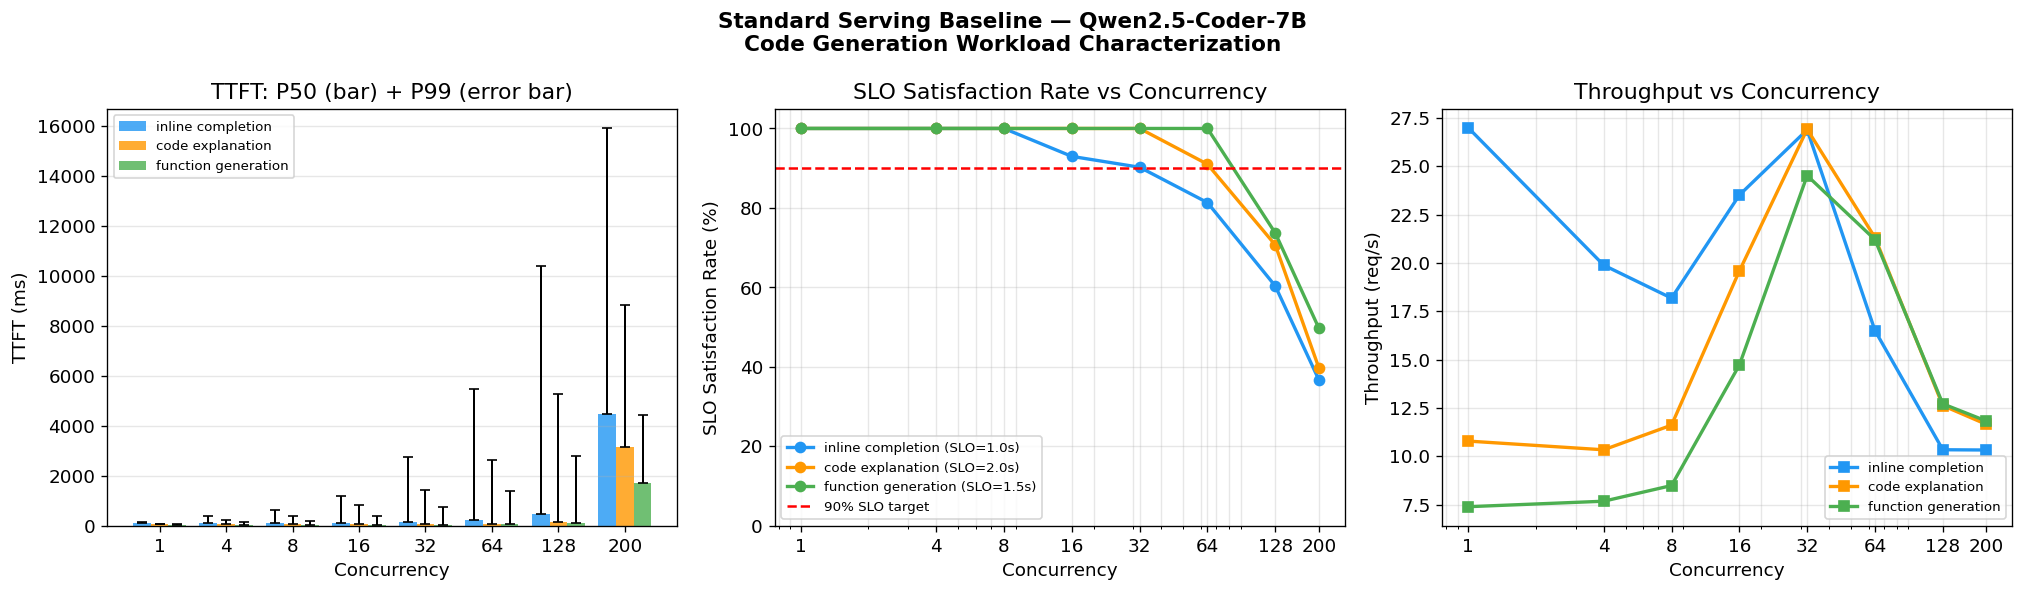


混合 Workload 结果（不在曲线图中）：
  concurrency=8: TTFT P50=68ms P99=576ms SLO=100% throughput=24.9req/s


In [17]:
# 画图
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import os

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

# ── 颜色和 profile 列表（与实验设置对齐）──────────────────
PROFILES = PROFILES_TO_TEST  # ["inline_completion", "code_explanation", "function_generation"]
COLORS = {
    "inline_completion":   '#2196F3',
    "code_explanation":    '#FF9800',
    "function_generation": '#4CAF50',
    "mixed":               '#9C27B0',
}

# ── 数据源：优先用内存里的 df_metrics，回退到 df ──────────
if 'df_metrics' in dir():
    df_plot = df_metrics.copy()
elif 'df' in dir():
    df_plot = df.copy()
else:
    raise RuntimeError("找不到结果 DataFrame")

# 排除 mixed（它只有一个 concurrency 点）
df_main = df_plot[df_plot['profile'].isin(PROFILES)].copy()

# 实际跑过的 concurrency 档位（从数据里取，避免和 CONCURRENCY_LEVELS 不一致）
concurrency_axis = sorted(df_main['concurrency'].unique())

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f"Standard Serving Baseline — {MODEL_NAME}\n"
    "Code Generation Workload Characterization",
    fontsize=13, fontweight='bold'
)

# ── 图1：TTFT P50 (bar) + P99 (error bar) ───────────────
ax = axes[0]
x = np.arange(len(concurrency_axis))
w = 0.8 / len(PROFILES)  # 自适应组宽

for i, profile in enumerate(PROFILES):
    pdata = (df_main[df_main['profile'] == profile]
             .set_index('concurrency')
             .reindex(concurrency_axis))
    p50s = pdata['ttft_p50'].values * 1000   # ms
    p99s = pdata['ttft_p99'].values * 1000

    offset = (i - (len(PROFILES) - 1) / 2) * w
    ax.bar(x + offset, p50s, w, color=COLORS[profile],
           alpha=0.8, label=profile.replace('_', ' '))

    # error bar：下端 0，上端 P99-P50
    yerr_lower = np.zeros_like(p50s)
    yerr_upper = np.maximum(p99s - p50s, 0)
    ax.errorbar(x + offset, p50s,
                yerr=[yerr_lower, yerr_upper],
                fmt='none', color='black', capsize=3, lw=1.2)

ax.set_title('TTFT: P50 (bar) + P99 (error bar)')
ax.set_xlabel('Concurrency')
ax_ttft.set_yscale('log')
ax_ttft.set_ylim(10, 30000)  # 10ms 到 30s
ax_ttft.set_ylabel('TTFT (ms, log scale)')
ax.set_xticks(x)
ax.set_xticklabels(concurrency_axis)
ax.legend(fontsize=8, loc='upper left')
ax.grid(axis='y', alpha=0.3)

# ── 图2：SLO Satisfaction Rate vs Concurrency ────────────
ax = axes[1]
for profile in PROFILES:
    pdata = (df_main[df_main['profile'] == profile]
             .sort_values('concurrency'))
    slo_target = WORKLOAD_PROFILES[profile]['TTFT_SLO']
    ax.plot(pdata['concurrency'], pdata['slo_rate'] * 100,
            marker='o', color=COLORS[profile], lw=2,
            label=f"{profile.replace('_', ' ')} (SLO={slo_target}s)")

ax.axhline(90, color='red', ls='--', lw=1.5, label='90% SLO target')
ax.set_title('SLO Satisfaction Rate vs Concurrency')
ax.set_xlabel('Concurrency')
ax.set_ylabel('SLO Satisfaction Rate (%)')
ax.set_ylim(0, 105)
ax.set_xscale('log')   # 并发档跨度大时用 log，密集低并发也能看清
ax.set_xticks(concurrency_axis)
ax.set_xticklabels(concurrency_axis)
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.3, which='both')

# ── 图3：Throughput vs Concurrency ───────────────────────
ax = axes[2]
for profile in PROFILES:
    pdata = (df_main[df_main['profile'] == profile]
             .sort_values('concurrency'))
    ax.plot(pdata['concurrency'], pdata['throughput_req_s'],
            marker='s', color=COLORS[profile], lw=2,
            label=profile.replace('_', ' '))

ax.set_title('Throughput vs Concurrency')
ax.set_xlabel('Concurrency')
ax.set_ylabel('Throughput (req/s)')
ax.set_xscale('log')
ax.set_xticks(concurrency_axis)
ax.set_xticklabels(concurrency_axis)
ax.legend(fontsize=8, loc='best')
ax.grid(alpha=0.3, which='both')

plt.tight_layout()

# ── 保存 ─────────────────────────────────────────────
# timestamp 优先用保存 cell 留下的；如果没跑过保存 cell，自己生成一个
if 'timestamp' not in dir():
    from datetime import datetime
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")

os.makedirs(DRIVE_RESULTS_DIR, exist_ok=True)
fig_path = f"{DRIVE_RESULTS_DIR}/baseline_plot_{timestamp}.png"
fig_pdf  = f"{DRIVE_RESULTS_DIR}/baseline_plot_{timestamp}.pdf"
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.savefig(fig_pdf,  bbox_inches='tight')   # 矢量图，论文用
print(f"图表已保存:")
print(f"  PNG: {fig_path}")
print(f"  PDF: {fig_pdf}")
plt.show()

# ── 顺手打印 mixed workload 结果（如果有）─────────────────
df_mixed = df_plot[df_plot['profile'] == 'mixed']
if len(df_mixed):
    print("\n混合 Workload 结果（不在曲线图中）：")
    for _, r in df_mixed.iterrows():
        print(f"  concurrency={r['concurrency']}: "
              f"TTFT P50={r['ttft_p50']*1000:.0f}ms "
              f"P99={r['ttft_p99']*1000:.0f}ms "
              f"SLO={r['slo_rate']*100:.0f}% "
              f"throughput={r['throughput_req_s']:.1f}req/s")

ISL Sweep 实验：13 档 × 100 请求
固定 OSL=250, 并发=8
───────────────────────────────────────────────────────
Warmup (20 requests at ISL=1024)...
  进度: 20/20 (20 成功)
Warmup done
───────────────────────────────────────────────────────
  进度: 100/100 (100 成功)
  ISL=  128: P50=   74ms  P99=  108ms  SLO@1s=100.0%
  进度: 100/100 (100 成功)
  ISL=  256: P50=   39ms  P99=  183ms  SLO@1s=100.0%
  进度: 100/100 (100 成功)
  ISL=  512: P50=   52ms  P99=  306ms  SLO@1s=100.0%
  进度: 100/100 (100 成功)
  ISL= 1024: P50=   86ms  P99=  551ms  SLO@1s=100.0%
  进度: 100/100 (100 成功)
  ISL= 1536: P50=  116ms  P99=  821ms  SLO@1s=100.0%
  进度: 100/100 (100 成功)
  ISL= 2048: P50=  151ms  P99=  978ms  SLO@1s= 99.0%
  进度: 100/100 (100 成功)
  ISL= 2560: P50=  181ms  P99= 1191ms  SLO@1s= 96.0%
  进度: 100/100 (100 成功)
  ISL= 3072: P50=  229ms  P99= 1457ms  SLO@1s= 95.0%
  进度: 100/100 (100 成功)
  ISL= 3584: P50=  264ms  P99= 1696ms  SLO@1s= 94.0%
  进度: 100/100 (100 成功)
  ISL= 4096: P50=  303ms  P99= 2010ms  SLO@1s= 94.0%
  进度: 100/100 (1

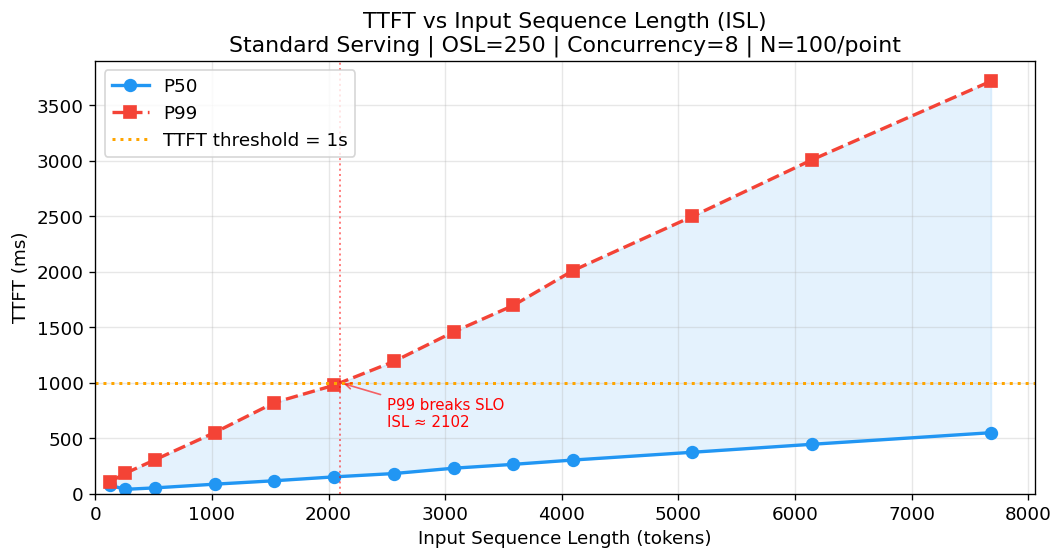


图保存: /content/drive/MyDrive/vllm_bench/results/isl_sweep_20260503_0347.png
ISL Sweep 完成


In [19]:
# 实验2：ISL Sweep — TTFT vs Input Sequence Length
import numpy as np
import asyncio
import nest_asyncio
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

nest_asyncio.apply()

# ── 实验参数 ────────────────────────────────────────────
ISL_VALUES = [128, 256, 512, 1024, 1536, 2048, 2560,
              3072, 3584, 4096, 5120, 6144, 7680]
FIXED_OSL  = 250
FIXED_CONC = 8
N_PER_ISL  = 100   # P99 需要 ≥100 才稳定

if 'timestamp' not in dir():
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")


# ── 主实验 ───────────────────────────────────────────────
async def run_isl_sweep():
    isl_results = []
    isl_traces  = []

    # Warmup
    print("Warmup (20 requests at ISL=1024)...")
    warm_reqs = [{
        "prompt":     generate_prompt(1024, seed=i),
        "max_tokens": FIXED_OSL,
        "target_isl": 1024,
        "target_osl": FIXED_OSL,
        "profile":    "warmup",
    } for i in range(20)]
    await run_benchmark(warm_reqs, FIXED_CONC)
    print("Warmup done\n" + "─" * 55)

    for isl in ISL_VALUES:
        # 每个请求独立 seed → 不同 prompt → 绕开 prefix cache
        requests = [{
            "prompt":     generate_prompt(isl, seed=isl * 10000 + i),
            "max_tokens": FIXED_OSL,
            "target_isl": isl,
            "target_osl": FIXED_OSL,
            "profile":    "isl_sweep",
        } for i in range(N_PER_ISL)]

        results = await run_benchmark(requests, FIXED_CONC)
        metrics = compute_metrics(results, slo_ttft=1.0)
        metrics["isl"] = isl
        metrics["n_requests"] = N_PER_ISL
        isl_results.append(metrics)

        # 存原始 traces
        from dataclasses import asdict

        for r in results:
            isl_traces.append({
                "isl":           isl,
                "ttft":          r.ttft,
                "total_time":    r.total_time,
                "tpot":          r.tpot,
                "target_isl":    r.target_isl,
                "target_osl":    r.target_osl,
                "output_tokens": r.output_tokens,
                "success":       r.success,
                "error":         r.error,
            })

        print(f"  ISL={isl:5d}: P50={metrics['ttft_p50']*1000:5.0f}ms  "
              f"P99={metrics['ttft_p99']*1000:5.0f}ms  "
              f"SLO@1s={metrics['slo_rate']*100:5.1f}%")

        await asyncio.sleep(2)  # cooldown

    return isl_results, isl_traces


print(f"ISL Sweep 实验：{len(ISL_VALUES)} 档 × {N_PER_ISL} 请求")
print(f"固定 OSL={FIXED_OSL}, 并发={FIXED_CONC}")
print("─" * 55)

isl_sweep_results, isl_sweep_traces = asyncio.get_event_loop().run_until_complete(
    run_isl_sweep()
)


# ── 保存 ────────────────────────────────────────────────
isl_df = pd.DataFrame(isl_sweep_results)
isl_traces_df = pd.DataFrame(isl_sweep_traces)

isl_csv         = f"{DRIVE_RESULTS_DIR}/isl_sweep_{timestamp}.csv"
isl_parquet     = f"{DRIVE_RESULTS_DIR}/isl_sweep_{timestamp}.parquet"
isl_traces_path = f"{DRIVE_RESULTS_DIR}/isl_sweep_traces_{timestamp}.parquet"

isl_df.to_csv(isl_csv, index=False)
isl_df.to_parquet(isl_parquet, index=False)
isl_traces_df.to_parquet(isl_traces_path, index=False)

print(f"\n保存:")
print(f"  metrics: {isl_csv}")
print(f"  traces:  {isl_traces_path}  ({len(isl_traces_df)} rows)")


# ── 可视化 ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.8))

p50_ms = isl_df['ttft_p50'] * 1000
p99_ms = isl_df['ttft_p99'] * 1000

ax.plot(isl_df['isl'], p50_ms,
        marker='o', color='#2196F3', lw=2, label='P50', markersize=7)
ax.plot(isl_df['isl'], p99_ms,
        marker='s', color='#F44336', lw=2, ls='--', label='P99', markersize=7)
ax.fill_between(isl_df['isl'], p50_ms, p99_ms,
                alpha=0.12, color='#2196F3')

# SLO 阈值线（
ax.axhline(1000, color='orange', ls=':', lw=1.8,
           label='TTFT threshold = 1s')

# 自动标注 P99 穿越 1s 的位置
crossings = np.where(np.diff((p99_ms.values > 1000).astype(int)) == 1)[0]
if len(crossings):
    idx = crossings[0]
    x1, x2 = isl_df['isl'].iloc[idx], isl_df['isl'].iloc[idx + 1]
    y1, y2 = p99_ms.iloc[idx], p99_ms.iloc[idx + 1]
    cross_isl = x1 + (1000 - y1) * (x2 - x1) / (y2 - y1)
    ax.axvline(cross_isl, color='red', ls=':', alpha=0.5, lw=1.2)
    ax.annotate(f'P99 breaks SLO\nISL ≈ {cross_isl:.0f}',
                xy=(cross_isl, 1000),
                xytext=(cross_isl + 400, 600),
                fontsize=9, color='red',
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.6))

ax.set_title(
    f'TTFT vs Input Sequence Length (ISL)\n'
    f'Standard Serving | OSL={FIXED_OSL} | Concurrency={FIXED_CONC} | '
    f'N={N_PER_ISL}/point'
)
ax.set_xlabel('Input Sequence Length (tokens)')
ax.set_ylabel('TTFT (ms)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
fig_png = f"{DRIVE_RESULTS_DIR}/isl_sweep_{timestamp}.png"
fig_pdf = f"{DRIVE_RESULTS_DIR}/isl_sweep_{timestamp}.pdf"
plt.savefig(fig_png, dpi=150, bbox_inches='tight')
plt.savefig(fig_pdf, bbox_inches='tight')
plt.show()

print(f"\n图保存: {fig_png}")
print("ISL Sweep 完成")

In [ ]:
'''
server_proc.terminate()
server_proc.wait()
print("vLLM 服务已关闭")
print(f"\n所有结果保存在: {DRIVE_RESULTS_DIR}")
!ls -lh {DRIVE_RESULTS_DIR}
'''